# 🚀 Practice Day 28

**📅 Date:** 2026-10-08  
📁 Category: Phase 4 · 캡스톤2(구독 서비스 이탈 Churn) (Round 2/3)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Investigate subscriber churn — who's leaving, and which signals (tenure, engagement, support issues) actually relate to it
  (구독자 이탈을 조사하기 — 누가 이탈하는지, tenure·참여도·CS 이슈 중 어떤 신호가 실제로 이탈과 관련 있는지)
- Compare churned vs retained subscribers and build your own view of what predicts churn here
  (이탈 고객과 유지 고객을 비교하고, 무엇이 이탈을 예측하는지 스스로 관점을 세워보기)

---
# 📂 Dataset

**Dataset Name:** GreenBox 밀키트 정기배송 — 구독자 데이터 / GreenBox Meal Kit Subscription — Subscriber Data

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** 230 meal-kit subscribers (single table), including plan type (Weekly/Biweekly), months subscribed (tenure_months), how often they skip their weekly box (weekly_skip_rate), number of support tickets filed (support_tickets), and whether they churned (0/1). Clean — no missing values or duplicates.
(230명의 밀키트 정기배송 구독자 데이터(단일 테이블)로, 요금제(Weekly/Biweekly), 가입 후 유지 개월수(tenure_months), 주간 배송 건너뛰기 비율(weekly_skip_rate), 고객지원 문의 건수(support_tickets), 이탈 여부(churned: 0/1)를 포함합니다. 결측치·중복 없이 깨끗합니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)
rng = np.random.default_rng(42)

# --- Generate meal-kit subscription data with realistic churn drivers ---
n = 230
plan_type = rng.choice(['Weekly', 'Biweekly'], size=n, p=[0.6, 0.4])
tenure_months = np.clip(rng.exponential(9, n), 1, 36).round().astype(int)
weekly_skip_rate = np.clip(rng.beta(1.5, 4, n), 0, 0.9).round(2)
support_tickets = rng.poisson(1.1, n)
support_tickets = support_tickets + (weekly_skip_rate > 0.5).astype(int) * rng.integers(0, 2, n)

signup_date = pd.to_datetime('2024-07-01') - pd.to_timedelta(tenure_months * 30, unit='D')

# churn probability: longer tenure lowers it; skip rate, support tickets, and Biweekly plan raise it
z = (
    -1.3
    - 0.09 * tenure_months
    + 3.0 * weekly_skip_rate
    + 0.35 * support_tickets
    + np.where(plan_type == 'Biweekly', 0.35, 0.0)
)
p_churn = 1 / (1 + np.exp(-z))
churned = rng.binomial(1, p_churn)

df = pd.DataFrame({
    'subscriber_id': [f'S{str(i+1).zfill(4)}' for i in range(n)],
    'plan_type': plan_type,
    'signup_date': signup_date,
    'tenure_months': tenure_months,
    'weekly_skip_rate': weekly_skip_rate,
    'support_tickets': support_tickets,
    'churned': churned
})
df = df.sample(frac=1, random_state=99).reset_index(drop=True)

df.head(10)


,subscriber_id,plan_type,signup_date,tenure_months,weekly_skip_rate,support_tickets,churned
0,S0144,Weekly,2024-05-02,2,0.16,2,0
1,S0073,Biweekly,2024-05-02,2,0.26,0,0
2,S0190,Weekly,2023-10-05,9,0.30,0,0
3,S0128,Weekly,2023-10-05,9,0.16,0,0
4,S0044,Weekly,2024-04-02,3,0.45,2,1
5,S0081,Biweekly,2024-03-03,4,0.33,2,0
6,S0125,Weekly,2023-10-05,9,0.30,3,1
7,S0120,Biweekly,2021-07-17,36,0.28,3,1
8,S0052,Weekly,2024-03-03,4,0.06,3,1
9,S0184,Weekly,2024-05-02,2,0.23,2,0


## Dataset Information

In [2]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   subscriber_id     230 non-null    str           
 1   plan_type         230 non-null    str           
 2   signup_date       230 non-null    datetime64[us]
 3   tenure_months     230 non-null    int64         
 4   weekly_skip_rate  230 non-null    float64       
 5   support_tickets   230 non-null    int64         
 6   churned           230 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 12.7 KB

Shape: (230, 7)


,subscriber_id,plan_type,signup_date,tenure_months,weekly_skip_rate,support_tickets,churned
count,230,230,230,230.000000,230.000000,230.000000,230.000000
unique,230,2,NaN,NaN,NaN,NaN,NaN
top,S0144,Weekly,NaN,NaN,NaN,NaN,NaN
freq,1,141,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2023-09-17 18:46:57.391304,9.573913,0.265957,1.191304,0.373913
min,NaN,NaN,2021-07-17 00:00:00,1.000000,0.010000,0.000000,0.000000
25%,NaN,NaN,2023-05-15 12:00:00,3.000000,0.130000,0.000000,0.000000
50%,NaN,NaN,2024-01-03 00:00:00,6.000000,0.230000,1.000000,0.000000
75%,NaN,NaN,2024-04-02 00:00:00,13.750000,0.380000,2.000000,1.000000
max,NaN,NaN,2024-06-01 00:00:00,36.000000,0.790000,6.000000,1.000000


---
# ❓ Business Questions

1. **(Analysis)** What is the overall churn rate, and how does it differ between the Weekly and Biweekly plans?
   (전체 이탈률은 몇 %이며, Weekly와 Biweekly 요금제 간 이탈률은 어떻게 다른가?)
2. **(Analysis)** How do churned and retained subscribers differ on average in tenure, skip rate, and support tickets?
   (이탈 고객과 유지 고객은 평균 tenure·skip rate·support tickets 측면에서 어떻게 다른가?)
3. **(Analysis)** Of tenure, skip rate, and support tickets, which appears most strongly related to churn?
   (tenure·skip rate·support tickets 중 이탈과 가장 관련이 깊어 보이는 요인은?)
4. **(Visualization)** Compare churn rate between the two plan types.
   (두 요금제 간 이탈률을 비교하면?)
5. **(Visualization)** Compare the distribution of tenure between churned and retained subscribers.
   (이탈 고객과 유지 고객의 tenure 분포를 비교하면?)

---
# 🔍 Data Cleaning Check


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
subscriber_id       0
plan_type           0
signup_date         0
tenure_months       0
weekly_skip_rate    0
support_tickets     0
churned             0
dtype: int64

Duplicate rows: 0

Dtypes
subscriber_id                  str
plan_type                      str
signup_date         datetime64[us]
tenure_months                int64
weekly_skip_rate           float64
support_tickets              int64
churned                      int64
dtype: object

Column names
['subscriber_id', 'plan_type', 'signup_date', 'tenure_months', 'weekly_skip_rate', 'support_tickets', 'churned']

Text columns — unique counts
subscriber_id    230
plan_type          2
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the overall churn rate, and how does it differ between the Weekly and Biweekly plans? (전체 이탈률과 요금제별 이탈률은?)

**Result:** Overall churn rate is **37.39%**. Biweekly is **44.94%**, Weekly is **32.62%**.
(전체 이탈률 37.39%. Biweekly 44.94%, Weekly 32.62%)

**Insight:** Biweekly churns about **12.3** percentage points more than Weekly — roughly 1.4x the Weekly rate.
(Biweekly가 Weekly보다 약 12.3%p 더 이탈 — Weekly의 약 1.4배)

In [4]:
# Question 1: overall churn rate + churn rate by plan_type
overall_churn_rate = round(df['churned'].mean() * 100, 2)
churn_rate_by_plan = (df.groupby('plan_type')['churned'].mean()*100).round(2)

print(f"Overall churn rate: {overall_churn_rate}%")
churn_rate_by_plan

Overall churn rate: 37.39%


plan_type
Biweekly    44.94
Weekly      32.62
Name: churned, dtype: float64

## Question 2

**Question:** How do churned and retained subscribers differ on average in tenure, skip rate, and support tickets? (이탈·유지 고객 간 평균 특성 차이는?)

**Result:** Churned subscribers average **6.15** months tenure, **32.17%** skip rate, **1.70** support tickets. Retained average **11.62** months, **23.26%** skip rate, **0.89** tickets.
(이탈 고객 평균: 6.15개월, 32.17%, 1.70건. 유지 고객 평균: 11.62개월, 23.26%, 0.89건)

**Insight:** Churned subscribers leave with about half the tenure of retained ones (**6.15** vs **11.62** months), skip boxes about **9**pp more often, and file almost twice the support tickets (**1.70** vs **0.89**).
(이탈 고객은 유지 고객의 절반 수준 개월수(6.15 vs 11.62개월)로 떠나고, 건너뛰기 비율은 약 9%p 더 높고, 문의 건수는 거의 2배(1.70 vs 0.89))

In [5]:
# Question 2: churned vs retained subscribers - average tenure, skip rate, support tickets
# Direction: group by 'churned' and compare the averages for each feature
user_behavior = df.groupby('churned').agg(
    tenure_months=('tenure_months', 'mean'),
    weekly_skip_rate=('weekly_skip_rate', 'mean'),
    support_tickets=('support_tickets', 'mean')
).reset_index()

user_behavior['weekly_skip_rate'] = user_behavior['weekly_skip_rate'] * 100

user_behavior

,churned,tenure_months,weekly_skip_rate,support_tickets
0,0,11.618056,23.263889,0.888889
1,1,6.151163,32.174419,1.697674


## Question 3

**Question:** Of tenure, skip rate, and support tickets, which appears most strongly related to churn? (이탈과 가장 관련 깊어 보이는 요인은?)

**Result:** By correlation with `churned`: `support_tickets` **0.325**, `tenure_months` **-0.295**, `weekly_skip_rate` **0.248**.
(churned와의 상관계수: support_tickets 0.325, tenure_months -0.295, weekly_skip_rate 0.248)

**Insight:** `support_tickets` has the strongest correlation with churn. The churned-vs-retained gap looked largest for `weekly_skip_rate` (**8.91**), but that gap is in percentage points while the others are in months and ticket counts — not a fair comparison across different units. Correlation, which is unit-free, says `support_tickets` is most related.
(support_tickets가 churned와 상관이 가장 강함. 이탈·유지 평균 차이로는 weekly_skip_rate(8.91)가 가장 커 보이지만, 그 값은 %p 단위이고 나머지는 개월·건수 단위라 서로 비교할 수 없음. 단위 없는 상관계수로 보면 support_tickets가 가장 관련 깊음)

In [6]:
# Question 3: which factor (tenure, skip rate, support tickets) relates most strongly to churn
# Direction: no single right method - correlations and the size of the churned-vs-retained gap are both fair game

print(df[['tenure_months', 'weekly_skip_rate', 'support_tickets', 'churned']].corr()['churned'])
user_behavior.loc[1] - user_behavior.loc[0]

tenure_months      -0.295265
weekly_skip_rate    0.248119
support_tickets     0.324936
churned             1.000000
Name: churned, dtype: float64


churned             1.000000
tenure_months      -5.466893
weekly_skip_rate    8.910530
support_tickets     0.808786
dtype: float64

---
# 📈 Visualization

**Chart 1:** Bar chart — churn rate by plan type (막대그래프: 요금제별 이탈률)

*Interpretation:* Biweekly's bar is taller at **44.94%** versus Weekly's **32.62%**, a gap of about **12.3**pp.
(Biweekly 막대가 44.94%로 Weekly 32.62%보다 높음. 약 12.3%p 차이)

---

**Chart 2:** Box plot — tenure distribution by churn status (박스플롯: 이탈 여부별 재직기간 분포)

*Interpretation:* The Churned box sits lower than Retained, matching the **6.15** vs **11.62** month averages from Question 2. Churned subscribers leave earlier and with less spread.
(Churned 박스가 Retained보다 아래쪽. Question 2의 6.15개월 vs 11.62개월 평균과 일치. 이탈 고객은 더 일찍, 더 좁게 몰려서 떠남)

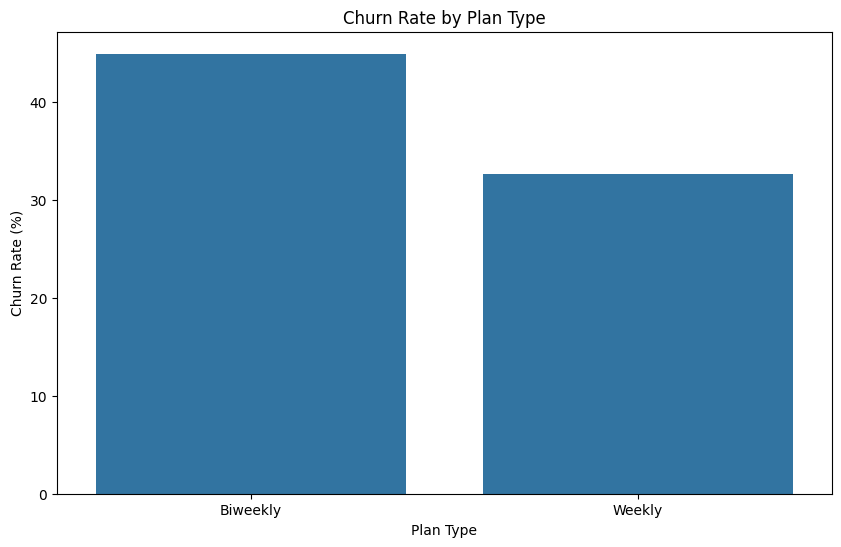

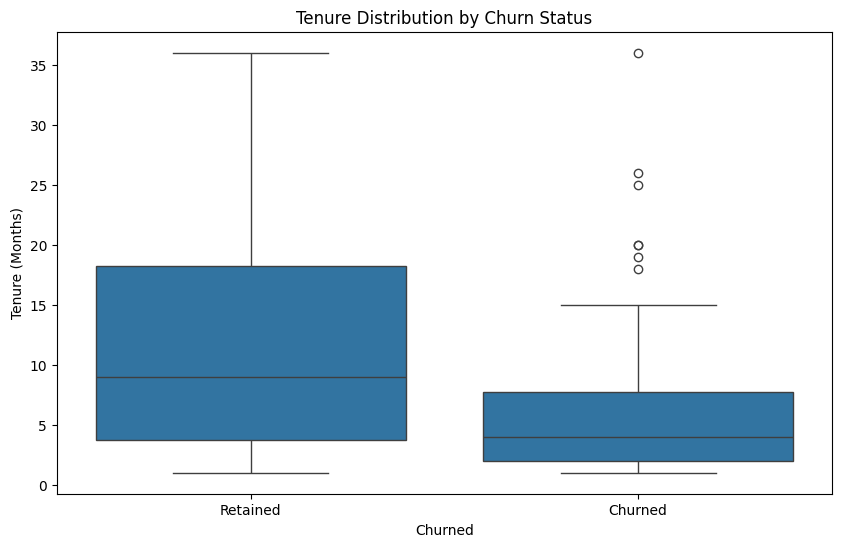

In [7]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: churn rate by plan type (bar)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=churn_rate_by_plan.index, y=churn_rate_by_plan.values, ax=ax)
ax.set_title('Churn Rate by Plan Type')
ax.set_xlabel('Plan Type')
ax.set_ylabel('Churn Rate (%)')
plt.show()

# Chart 2: tenure distribution by churn status (box plot)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='churned', y='tenure_months', data=df, ax=ax)
ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Churned')
ax.set_ylabel('Tenure (Months)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Retained', 'Churned'])
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Overall churn is **37.39%**, and Biweekly subscribers churn more than Weekly (**44.94%** vs **32.62%**).
  (전체 이탈률 37.39%. Biweekly가 Weekly보다 더 이탈(44.94% vs 32.62%))
- Churned subscribers leave at about half the tenure of retained ones (**6.15** vs **11.62** months) and file almost twice the support tickets (**1.70** vs **0.89**).
  (이탈 고객은 유지 고객 절반 수준 개월수(6.15 vs 11.62개월)에 떠나고, 문의는 거의 2배(1.70 vs 0.89))
- `support_tickets` has the strongest correlation with churn (**0.325**) once compared on a unit-free basis, ahead of `tenure_months` (**-0.295**) and `weekly_skip_rate` (**0.248**).
  (단위 없이 비교하면 support_tickets가 churn과 가장 강한 상관(0.325). tenure_months(-0.295), weekly_skip_rate(0.248)보다 앞섬)

---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Flag subscribers with **2+** support tickets early — that feature has the strongest correlation with churn (**0.325**).
   (문의 2건 이상인 구독자를 조기에 표시하기. churn과 상관이 가장 강함(0.325))
2. Target retention outreach around month **6**, since churned subscribers leave at about half the tenure of retained ones (**6.15** vs **11.62** months).
   (6개월 시점에 리텐션 아웃리치 집중. 이탈 고객은 유지 고객 절반 수준 개월수에 떠남(6.15 vs 11.62개월))
3. Review the Biweekly plan's experience — it churns **12.3**pp more than Weekly (**44.94%** vs **32.62%**).
   (Biweekly 요금제 경험 점검. Weekly보다 12.3%p 더 이탈(44.94% vs 32.62%))

---
# ❌ Mistakes
*What mistakes did I make today?*

- Compared the raw churned-vs-retained gaps across tenure, skip rate, and support tickets as if they were on the same scale. `weekly_skip_rate`'s gap (**8.91**) looked biggest, but it's in percentage points while the others are in months and ticket counts — not comparable.
  (이탈·유지 평균 차이를 단위 다른 세 변수끼리 그대로 비교함. weekly_skip_rate 차이(8.91)가 가장 커 보였지만 %p 단위라 개월·건수 단위와 비교 불가)
- Nearly concluded `weekly_skip_rate` was the strongest factor from that raw gap alone, before checking the unit-free correlation, which actually ranks `support_tickets` highest.
  (단위 없는 상관계수를 확인하기 전에, 그 원단위 차이만 보고 weekly_skip_rate가 가장 강한 요인이라고 결론 내릴 뻔함. 실제론 support_tickets가 상관계수 1위)

---
# ✅ What I Learned
*Today's biggest lesson*

- Correlation is unit-free, so it's the fair way to compare how strongly different variables relate to an outcome. A raw mean difference isn't comparable across variables with different units.
  (상관계수는 단위가 없어서 여러 변수가 결과와 얼마나 관련 있는지 비교하는 공정한 기준. 원단위 평균 차이는 단위가 다른 변수끼리 비교 불가)
- "Related to" (correlation) and "causes" are different claims — this kind of analysis can only support the first.
  ("관련 있다"(상관)와 "일으킨다"(인과)는 다른 주장. 이런 분석은 전자만 뒷받침함)
- Business Questions can ask for two things in one sentence (overall rate *and* by-plan rate) — easy to answer only the second half.
  (Business Question이 한 문장에 두 가지(전체 비율과 요금제별 비율)를 물을 수 있음. 뒷부분만 답하기 쉬움)

---
# 🧠 Reflection

**What was difficult?**
Deciding which of the two Question 3 methods (correlation vs raw gap) to trust when they pointed to different variables.
(Question 3의 두 방법(상관계수 vs 원단위 차이)이 서로 다른 변수를 가리킬 때 어느 쪽을 믿어야 할지 정하는 것)

**Why?**
`weekly_skip_rate`'s average gap was shown in percentage points (×100) in Question 2, while tenure is in months and support tickets is a plain count — three different units sitting in the same table.
(weekly_skip_rate의 평균 차이는 Question 2에서 %p(×100)로 표시됐고, tenure는 개월, support_tickets는 그냥 건수 — 같은 표에 단위가 세 개 다름)

**How did I solve it?**
Trusted correlation over the raw gap, since correlation is unit-free and comparable across variables regardless of their original scale.
(원단위 차이보다 상관계수를 신뢰함. 상관계수는 단위가 없어 원래 스케일과 상관없이 변수끼리 비교 가능)

**What would I do differently next time?**
Check whether every column in a comparison table shares the same unit before reading which number is "biggest."
(어떤 숫자가 "가장 크다"고 읽기 전에, 비교 표의 모든 열이 같은 단위인지 먼저 확인하기)

---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
Churn rate by group, churned-vs-retained comparison, and reading correlation are clear.
(그룹별 이탈률, 이탈·유지 비교, 상관계수 읽기는 이해함)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
Catching the unit mismatch between the raw gap and the correlation was the new part.
(원단위 차이와 상관계수 사이의 단위 불일치를 잡아내는 것이 새로웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 29 — Pandas basics (Round 2/5)
  (Pandas 기초 복습)